In [12]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras import models, layers

In [13]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [14]:
model = models.Sequential([
    layers.Input(shape=(28,28)),

    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,506 (103.54 KB)

 Trainable params: 26,506 (103.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28)),

    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

In [15]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [27]:
model.weights

[<Variable path=sequential_1/dense_3/kernel, shape=(784, 32), dtype=float32, value=[[ 0.06736443 -0.07324818 -0.03603121 ... -0.03395982 -0.08199552
    0.03366205]
  [-0.02000866 -0.02785223  0.07153171 ...  0.02991001 -0.05488747
    0.05469086]
  [-0.08010487  0.04537246 -0.01876026 ... -0.05537567 -0.07311376
   -0.00796834]
  ...
  [ 0.07870438 -0.06764293 -0.0558012  ...  0.07319259  0.01249953
   -0.08151846]
  [ 0.05856792 -0.07493241  0.05494592 ...  0.00296555 -0.04771389
    0.03785757]
  [-0.03729331 -0.01188754 -0.07361019 ...  0.06073738 -0.01769869
    0.05246364]]>,
 <Variable path=sequential_1/dense_3/bias, shape=(32,), dtype=float32, value=[ 0.6199534  -0.16890782 -0.21199591 -0.04229844 -0.51785105 -0.02984749
  -0.02280591 -0.12107238  0.6718172  -0.03040355 -0.681885   -0.02323037
  -0.0260376  -0.09816824 -0.02972484  1.333397   -0.04334006  0.19791852
   0.17551368 -0.14150706 -0.04069024 -0.05532262 -0.11368503 -0.14323983
  -0.05268764 -0.04525989 -0.6329635  -

In [23]:
history = model.fit(x_train, y_train, epochs=25, batch_size=60, validation_split=0.1)
history = history.history

Epoch 1/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9475 - loss: 0.1919 - val_accuracy: 0.9488 - val_loss: 0.2245
Epoch 2/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9484 - loss: 0.1925 - val_accuracy: 0.9513 - val_loss: 0.2077
Epoch 3/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9504 - loss: 0.1860 - val_accuracy: 0.9453 - val_loss: 0.2296
Epoch 4/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9498 - loss: 0.1863 - val_accuracy: 0.9510 - val_loss: 0.2099
Epoch 5/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9519 - loss: 0.1791 - val_accuracy: 0.9518 - val_loss: 0.2023
Epoch 6/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9515 - loss: 0.1768 - val_accuracy: 0.9468 - val_loss: 0.2149
Epoch 7/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9518 - loss: 0.1749 - val_accuracy: 0.9525 - val_loss: 0.1937
Epoch 8/25
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9539 - loss: 0.1698 - val_accuracy: 0.

(0.0, 1.0)

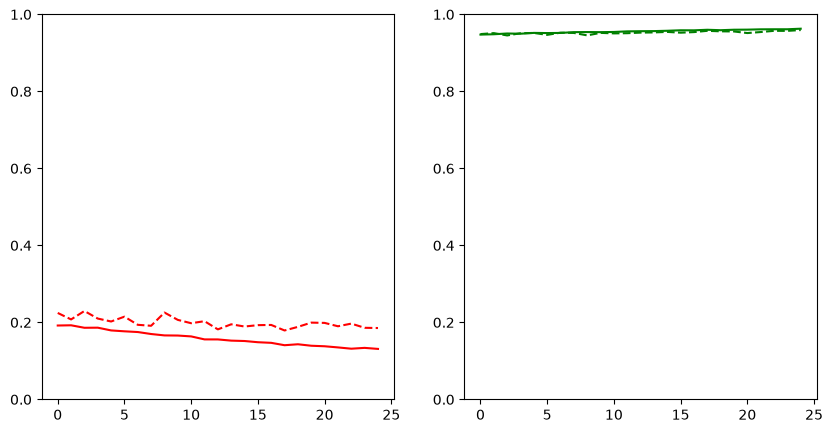

In [25]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(history["loss"],"r", label="train_loss")
plt.plot(history["val_loss"],"r--", label="val_loss")

plt.ylim ((0,1))

plt.subplot(122)
plt.plot(history["accuracy"],"g", label="train_accuracy")
plt.plot(history["val_accuracy"],"g--", label="val_accuracy")
plt.ylim ((0,1))
# plt.plot(model.loss_curve_, "r", label="Loss")

In [26]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9478 - loss: 0.2393


[0.23925548791885376, 0.9477999806404114]

In [22]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step


ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets